# EDA — Hinglish Sentiment Analysis

**Exploratory Data Analysis for SemEval 2020 Task 9**

Run this notebook before building any model.  
The figures you generate here become Section 4 (Dataset) of your paper.

---
Run order:
1. `python src/preprocess.py` first
2. Then open and run all cells in this notebook

In [2]:
# Cell 1 — Imports and data loading

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Reproducibility
random.seed(42)
np.random.seed(42)

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

os.makedirs('results', exist_ok=True)

# Load the cleaned dataset produced by preprocess.py
df = pd.read_csv('../data/processed/clean_data.csv')

LABEL_NAMES = {0: 'Positive', 1: 'Negative', 2: 'Neutral'}
df['sentiment'] = df['label'].map(LABEL_NAMES)

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nNull values:\n{df.isnull().sum()}')
print(f'\nFirst 10 rows:')
df.head(10)

Shape: (15130, 3)
Columns: ['text', 'label', 'sentiment']

Null values:
text         0
label        0
sentiment    0
dtype: int64

First 10 rows:


,text,label,sentiment
0,adilnisarbutt pakistan ka ghra tauq he pakista...,1,Negative
1,madarchod mulle ye mathura me nahi dikha tha j...,1,Negative
2,narendramodi manya pradhan mantri mahoday shri...,0,Positive
3,atheist krishna jcb full trend me chal rahi aa,0,Positive
4,abhisharsharma ravishkumarblog loksabha me jan...,0,Positive
5,noirnaveed angelahana6 cricketworldcup bhosdik...,1,Negative
6,love u bhaijan father son bharat iambharat bha...,0,Positive
7,manojgajjar111 tumhara pass abh deemagh hai na...,1,Negative
8,mahlogo nolo weni ankere o gae this weekend,0,Positive
9,aurangzeb aimim sachins40805591 lage raho mull...,1,Negative


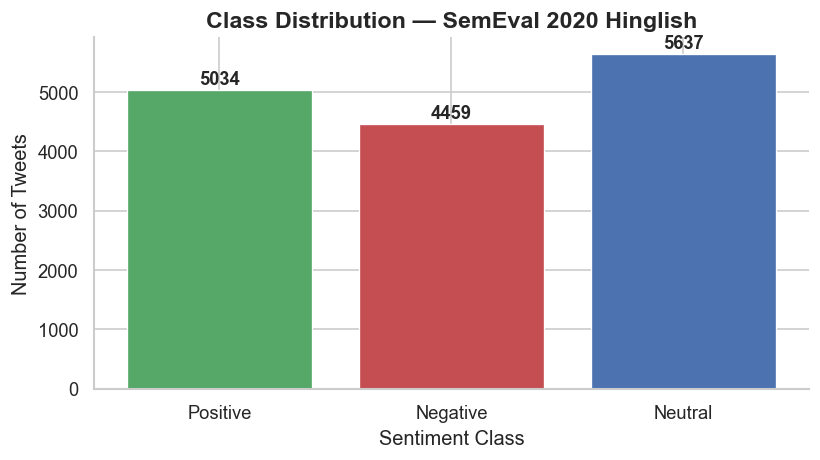


Class distribution:
sentiment
Positive    5034
Negative    4459
Neutral     5637
Name: count, dtype: int64

Class proportions:
sentiment
Positive    0.333
Negative    0.295
Neutral     0.373
Name: count, dtype: float64


In [3]:
# Cell 2 — Class distribution
# Note any class imbalance — if one class is much smaller, mention it in your paper
# and consider whether weighted F1 or oversampling is needed.

counts = df['sentiment'].value_counts().reindex(['Positive', 'Negative', 'Neutral'])

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values, color=['#55A868', '#C44E52', '#4C72B0'],
              edgecolor='white', linewidth=0.8)

# Add count labels on each bar
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Class Distribution — SemEval 2020 Hinglish', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment Class', fontsize=12)
ax.set_ylabel('Number of Tweets', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('results/class_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

print('\nClass distribution:')
print(counts)
print(f'\nClass proportions:')
print((counts / counts.sum()).round(3))

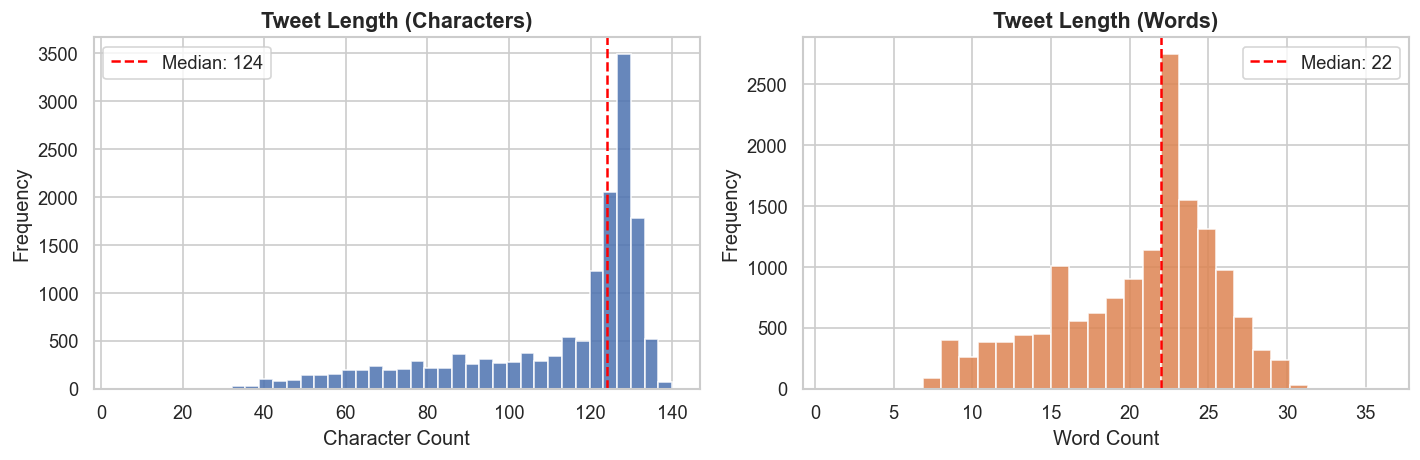

Tweet length statistics:
       char_length  word_count
count     15130.00    15130.00
mean        111.99       20.49
std          24.03        5.14
min           5.00        1.00
25%         101.00       17.00
50%         124.00       22.00
75%         128.00       24.00
max         140.00       36.00


In [4]:
# Cell 3 — Tweet length analysis
# Report mean/median tweet length in your paper's Dataset section.

df['char_length'] = df['text'].str.len()
df['word_count']  = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Character length histogram
axes[0].hist(df['char_length'], bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].axvline(df['char_length'].median(), color='red', linestyle='--', label=f"Median: {df['char_length'].median():.0f}")
axes[0].set_title('Tweet Length (Characters)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Word count histogram
axes[1].hist(df['word_count'], bins=30, color='#DD8452', edgecolor='white', alpha=0.85)
axes[1].axvline(df['word_count'].median(), color='red', linestyle='--', label=f"Median: {df['word_count'].median():.0f}")
axes[1].set_title('Tweet Length (Words)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/tweet_length_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

print('Tweet length statistics:')
print(df[['char_length', 'word_count']].describe().round(2))

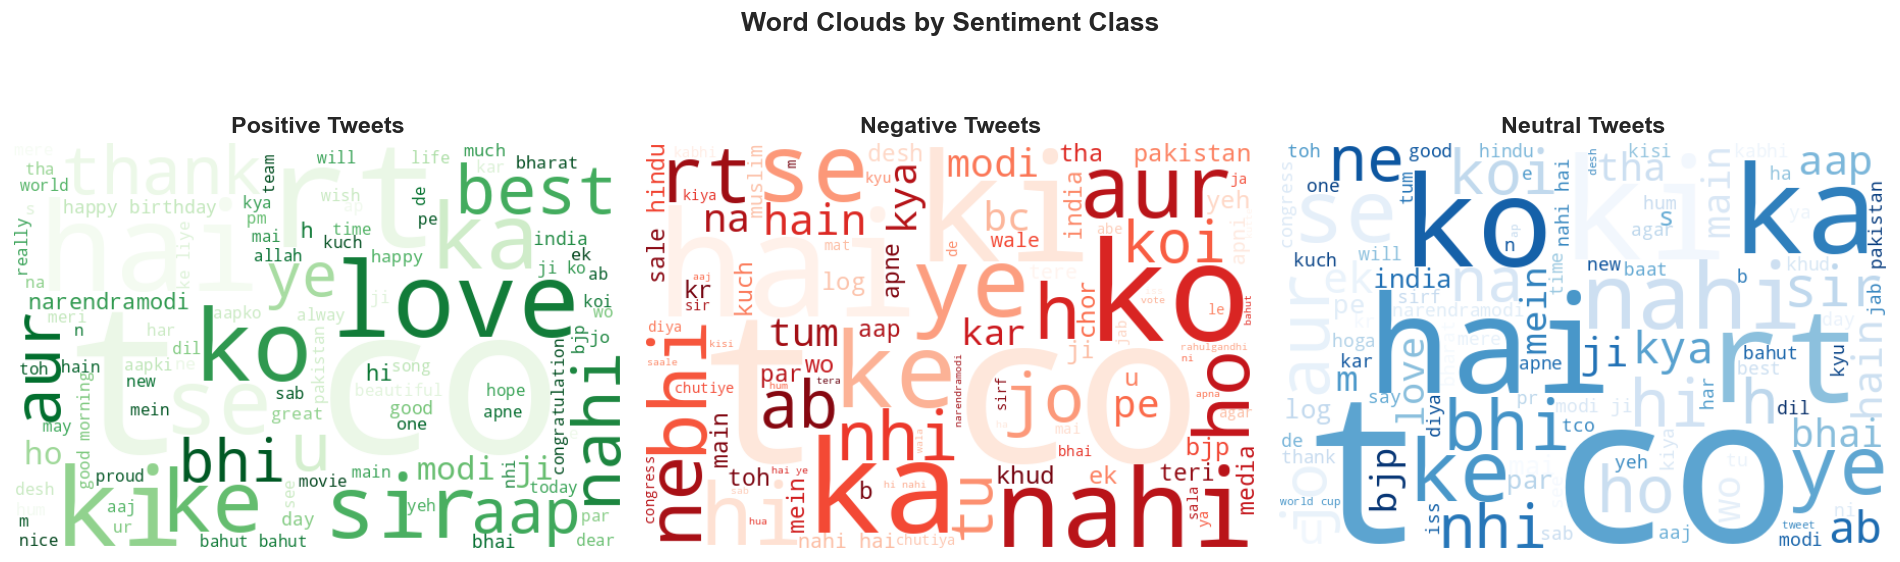

Word clouds saved to results/wordclouds.png


In [5]:
# Cell 4 — Word clouds per sentiment class
# Observe which words dominate each class.
# This informs your error analysis — e.g. if sarcastic positives look negative.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colours = {'Positive': 'Greens', 'Negative': 'Reds', 'Neutral': 'Blues'}

for ax, sentiment in zip(axes, ['Positive', 'Negative', 'Neutral']):
    text_corpus = ' '.join(df[df['sentiment'] == sentiment]['text'].tolist())

    wc = WordCloud(
        width=600,
        height=400,
        max_words=100,
        background_color='white',
        colormap=colours[sentiment],
        random_state=42,
    ).generate(text_corpus)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment} Tweets', fontsize=14, fontweight='bold')
    ax.axis('off')

fig.suptitle('Word Clouds by Sentiment Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/wordclouds.png', dpi=200, bbox_inches='tight')
plt.show()
print('Word clouds saved to results/wordclouds.png')

In [6]:
# Cell 5 — Manual sample inspection
# Look at 5 random examples per class.
# Note code-mixing patterns, Devanagari presence, sarcasm.
# Describe what you observe in 1-2 sentences in your paper's Dataset section.

for sentiment in ['Positive', 'Negative', 'Neutral']:
    print(f'\n{"-" * 60}')
    print(f'  Sample {sentiment} tweets')
    print(f'{"-" * 60}')
    samples = df[df['sentiment'] == sentiment]['text'].sample(5, random_state=42).tolist()
    for i, tweet in enumerate(samples, 1):
        print(f'  {i}. {tweet}')


------------------------------------------------------------
  Sample Positive tweets
------------------------------------------------------------
  1. rt shaheer speaks yrrrr amna fatima says happy birthday may you have many more bless you
  2. maitri xx beingsalmankhan mai dil se duaa karta hu aap aane wali bharat movie super hit ho
  3. inidnan i say delhi they hear tu janta nahi mera baap kaun hai
  4. kuwaramitsingh udayasrao tajinderbagga mamataofficial jai shree ram bhagwan aapka bhala kare
  5. rt jamielidell steadystatefate hey the pod is up with the ad slot thanks so much for the sponsorship we at howa salute you these

------------------------------------------------------------
  Sample Negative tweets
------------------------------------------------------------
  1. yadavdimples madam ji aap apne party ka laptops apne pass rakhe up ke students bahut ache hai unhe kisi dee hui bhikh nahi chahiye
  2. tum hote kon ho msd ke bare me aise bolne wale khud to kuch kar nhi sakte

In [7]:
# Cell 6 — Summary statistics for the paper's Dataset table

print('=' * 50)
print('  Dataset Summary (SemEval 2020 Task 9)')
print('=' * 50)
print(f'  Total samples        : {len(df)}')
print(f'  Positive             : {(df["label"] == 0).sum()} ({(df["label"] == 0).mean()*100:.1f}%)')
print(f'  Negative             : {(df["label"] == 1).sum()} ({(df["label"] == 1).mean()*100:.1f}%)')
print(f'  Neutral              : {(df["label"] == 2).sum()} ({(df["label"] == 2).mean()*100:.1f}%)')
print(f'  Mean tweet length    : {df["word_count"].mean():.1f} words')
print(f'  Median tweet length  : {df["word_count"].median():.1f} words')
print(f'  Max tweet length     : {df["word_count"].max()} words')
print('=' * 50)
print('Copy these numbers into Table 1 of your paper.')

  Dataset Summary (SemEval 2020 Task 9)
  Total samples        : 15130
  Positive             : 5034 (33.3%)
  Negative             : 4459 (29.5%)
  Neutral              : 5637 (37.3%)
  Mean tweet length    : 20.5 words
  Median tweet length  : 22.0 words
  Max tweet length     : 36 words
Copy these numbers into Table 1 of your paper.
